# **Ensemble Kalman RMLE - Demonstration of linear theory**

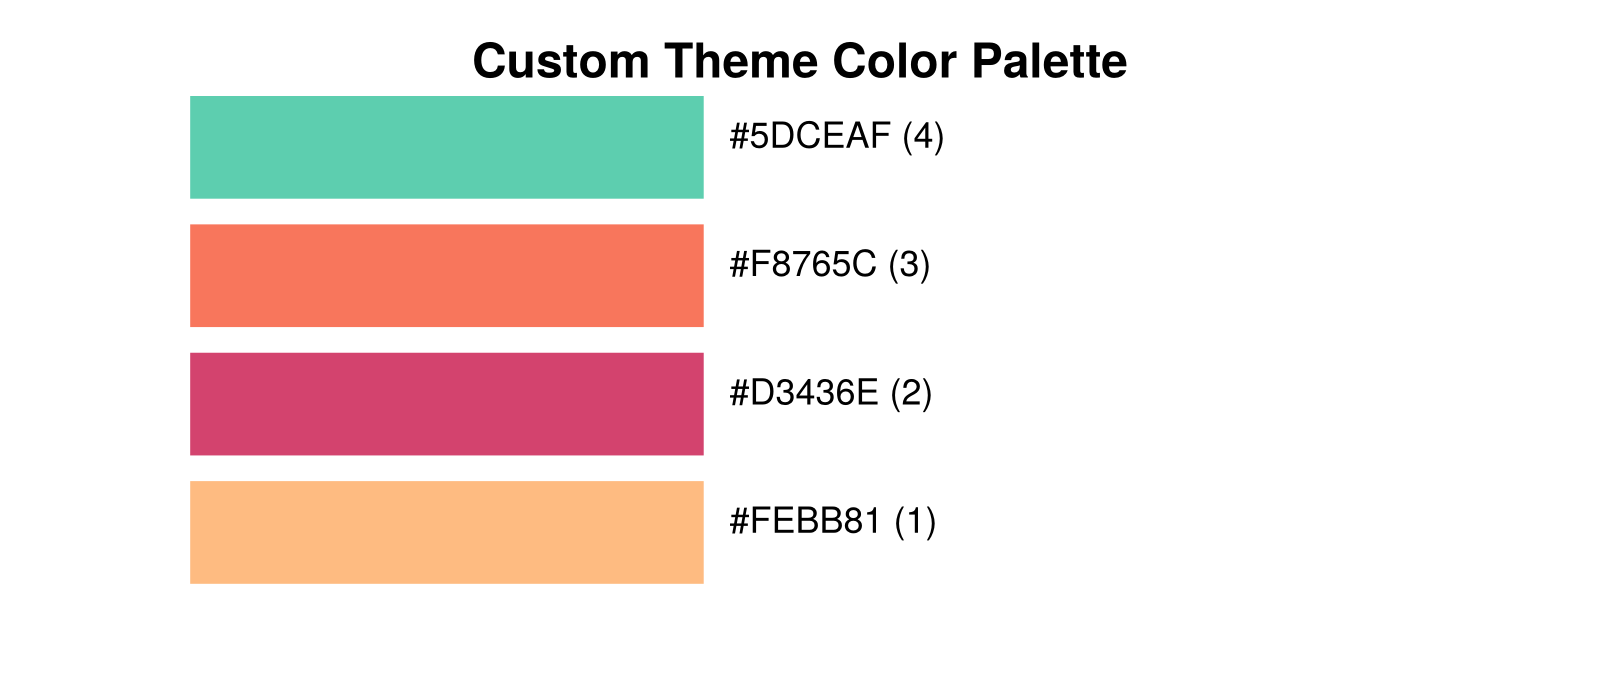

_samplecov (generic function with 1 method)

In [1]:
using OralQual
using LinearAlgebra
using Random
using CairoMakie
using Distributions
using ColorSchemes
include("PrettyPlots.jl")


@inline colmean(V::AbstractMatrix) = vec(mean(V, dims=2))

function _samplecov(V::AbstractMatrix)
    # computes sample covariance (column-wise)
    J = size(V, 2)
    μ = colmean(V)
    X = V .- μ
    return (X * X') / (J-1)
end

## **Problem Setup**
In this demo, we will illustrate the ability of our algorithm to perform randomized maximum likelihood estimation, and we will numerically illustrate our convergence theory. We will do so by studying the problem:

$$
\min_{\mathbf{v}\in\mathbb{R}^n} \|\mathbf{y} - \mathbf{Hv}\|_{\boldsymbol{\Gamma}^{-1}}^2,
$$

where $\mathbf{y}\in\mathbb{R}^n$, $\mathbf{v}\in\mathbb{R}^d$, $\mathbf{H}\in\mathbb{R}^{n\times d}$, and $\boldsymbol{\Gamma}\in\mathbb{R}^{n\times n}$ is a positive definite weight matrix.